# Think 文本 vs 图像去噪:步数蒸馏后的延迟瓶颈实验

## 假设

BAGEL 的 `think=True` 生图模式里,先自回归生成一段 `<think>...</think>` 规划文本,再做 flow-matching 图像去噪。这两条路径的开销特征完全不同:

- **图像去噪**(`Bagel.generate_image`):默认 50 步,每步最多 3 次 forward(主条件 + `cfg_text` + `cfg_img` 双重 CFG),每次并行处理 ~4096 个 image token(1024x1024 分辨率)——算力密集、高并行度。
- **think 文本**(`Bagel.generate_text`):朴素贪心/采样自回归循环,**没有 CFG**,每步只处理 1 个新 token——访存带宽瓶颈,不受图像侧任何加速手段影响。

**假设**:对图像侧做"步数蒸馏"(减少步数 + 去掉 CFG)后,图像去噪开销大幅塌缩,而 think 文本解码完全不受影响——整个 pipeline 的延迟瓶颈会从图像侧转移到文本侧。

## ⚠️ 实验局限性(务必先读)

1. **手上没有真实的步数蒸馏 checkpoint**。本实验用原始 `BAGEL-7B-MoT` 权重在推理时模拟"蒸馏后"的计算量特征(调小 `num_timesteps` + 关闭 CFG `cfg_text_scale=cfg_img_scale=1.0`)。**这只验证时延/计算量结构假设,不代表图像质量**——没有蒸馏训练过,少步数下生成质量会明显下降(本notebook末尾会展示对比图,不回避这一点)。
2. 额外测试 `enable_taylorseer=True`(仓库里已实现的训练-free 加速机制)作为第二个独立变量,交叉验证结论是否对不同加速机制都成立。
3. 结果与硬件强相关,绝对数值不能跨机器比较,只有同一次运行内的相对比较(`fraction_think`)有意义。
4. 假设单 GPU、bf16、无 `accelerate` device_map(多卡/量化会引入额外的计时混淆因素)。


## 1. 环境 / import

In [1]:
import os
import sys
import json
import time
import random
from copy import deepcopy
from contextlib import contextmanager

# ── 路径修正: 把项目根目录加入 sys.path ──
_proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_proj_root, "data")):
    if _proj_root not in sys.path:
        sys.path.insert(0, _proj_root)
    os.chdir(_proj_root)
else:
    raise RuntimeError(f"找不到项目根目录(data/ 目录) from {os.getcwd()}")
print(f"workdir: {os.getcwd()}")

import numpy as np
import torch

try:
    import pandas as pd
except ImportError:
    os.system(f"{sys.executable} -m pip install pandas")
    import pandas as pd

try:
    from scipy.stats import wilcoxon
except ImportError:
    os.system(f"{sys.executable} -m pip install scipy")
    from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

from safetensors.torch import load_file
from data.data_utils import add_special_tokens
from data.transforms import ImageTransform
from modeling.bagel import (
    BagelConfig, Bagel, Qwen2Config, Qwen2ForCausalLM, SiglipVisionConfig, SiglipVisionModel
)
from modeling.qwen2 import Qwen2Tokenizer
from modeling.autoencoder import load_ae
from inferencer import InterleaveInferencer, GEN_THINK_SYSTEM_PROMPT

assert torch.cuda.is_available(), "This benchmark needs a CUDA GPU."
print("torch:", torch.__version__)
print("device:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))
try:
    import flash_attn
    print("flash_attn:", flash_attn.__version__)
except ImportError:
    print("flash_attn: not installed")

workdir: /home/wuwenxuan03/bagel
torch: 2.5.1+cu121
device: NVIDIA GeForce RTX 4090
capability: (8, 9)
flash_attn: 2.5.8


## 2. 单卡模型加载

沿用 `eval/gen/gen_images_mp.py` 的加载方式(直接 `model.to(device).eval()`),**不用** `inference.ipynb` 里的 `accelerate` `device_map` 多卡 dispatch 方式——那种方式会插入跨设备拷贝的 forward hook,干扰计时。

如果你的显卡装不下完整 bf16 权重(~28GB),必须改用多卡或量化模式,请保证本次实验所有 condition 都用同一套加载配置,这样条件之间的相对比较(`fraction_think`)依然有效,只是绝对时间的可比性会下降。


In [2]:
MODEL_PATH = "/home/wuwenxuan03/bagel/BAGEL-7B-MoT"
DEVICE = "cuda:0"  # inferencer 仍以 cuda:0 为主设备,accelerate 会自动管理跨卡 forward

from accelerate import infer_auto_device_map, load_checkpoint_and_dispatch, init_empty_weights

llm_config = Qwen2Config.from_json_file(os.path.join(MODEL_PATH, "llm_config.json"))
llm_config.qk_norm = True
llm_config.tie_word_embeddings = False
llm_config.layer_module = "Qwen2MoTDecoderLayer"

vit_config = SiglipVisionConfig.from_json_file(os.path.join(MODEL_PATH, "vit_config.json"))
vit_config.rope = False
vit_config.num_hidden_layers = vit_config.num_hidden_layers - 1

vae_model, vae_config = load_ae(local_path=os.path.join(MODEL_PATH, "ae.safetensors"))

config = BagelConfig(
    visual_gen=True,
    visual_und=True,
    llm_config=llm_config,
    vit_config=vit_config,
    vae_config=vae_config,
    vit_max_num_patch_per_side=70,
    connector_act="gelu_pytorch_tanh",
    latent_patch_size=2,
    max_latent_size=64,
)

with init_empty_weights():
    language_model = Qwen2ForCausalLM(llm_config)
    vit_model = SiglipVisionModel(vit_config)
    model = Bagel(language_model, vit_model, config)
    model.vit_model.vision_model.embeddings.convert_conv2d_to_linear(vit_config, meta=True)

tokenizer = Qwen2Tokenizer.from_pretrained(MODEL_PATH)
tokenizer, new_token_ids, _ = add_special_tokens(tokenizer)

# ── accelerate device_map 多卡分发 ──
max_mem_per_gpu = "22GiB"
device_map = infer_auto_device_map(
    model,
    max_memory={i: max_mem_per_gpu for i in range(torch.cuda.device_count())},
    no_split_module_classes=["Bagel", "Qwen2MoTDecoderLayer"],
)
print("device_map:", device_map)

same_device_modules = [
    "language_model.model.embed_tokens", "time_embedder", "latent_pos_embed",
    "vae2llm", "llm2vae", "connector", "vit_pos_embed",
]
first_device = device_map.get(same_device_modules[0])
for k in same_device_modules:
    device_map[k] = first_device if k in device_map else "cuda:0"

model = load_checkpoint_and_dispatch(
    model,
    checkpoint=os.path.join(MODEL_PATH, "ema.safetensors"),
    device_map=device_map,
    offload_buffers=True,
    dtype=torch.bfloat16,
    force_hooks=True,
    offload_folder="/tmp/offload",
)
model = model.eval()

vae_model = vae_model.to(DEVICE).eval()

vae_transform = ImageTransform(1024, 512, 16)
vit_transform = ImageTransform(980, 224, 14)

print("Model loaded with accelerate device_map (multi-GPU), inferencer on", DEVICE)

The safetensors archive passed at /home/wuwenxuan03/bagel/BAGEL-7B-MoT/ema.safetensors does not contain metadata. Make sure to save your model with the `save_pretrained` method. Defaulting to 'pt' metadata.


device_map: OrderedDict([('language_model.model.embed_tokens', 0), ('language_model.model.layers.0', 0), ('language_model.model.layers.1', 0), ('language_model.model.layers.2', 0), ('language_model.model.layers.3', 0), ('language_model.model.layers.4', 0), ('language_model.model.layers.5', 0), ('language_model.model.layers.6', 0), ('language_model.model.layers.7', 0), ('language_model.model.layers.8', 0), ('language_model.model.layers.9', 0), ('language_model.model.layers.10', 1), ('language_model.model.layers.11', 1), ('language_model.model.layers.12', 1), ('language_model.model.layers.13', 1), ('language_model.model.layers.14', 1), ('language_model.model.layers.15', 1), ('language_model.model.layers.16', 1), ('language_model.model.layers.17', 1), ('language_model.model.layers.18', 1), ('language_model.model.layers.19', 1), ('language_model.model.layers.20', 1), ('language_model.model.layers.21', 1), ('language_model.model.layers.22', 2), ('language_model.model.layers.23', 2), ('langu

  0%|          | 0/1223 [00:00<?, ?w/s]

We've detected an older driver with an RTX 4000 series GPU. These drivers have issues with P2P. This can affect the multi-gpu inference when using accelerate device_map.Please make sure to update your driver to the latest version which resolves this.


Model loaded with accelerate device_map (multi-GPU), inferencer on cuda:0


## 3. `InterleaveInferencer` + 三个工具函数

- `set_all_seeds`:固定随机种子,控制 `prepare_vae_latent` 里初始噪声的复现性。
- `reset_taylorseer_state`:**每个 trial 前后都必须调用**。`Qwen2MoTDecoderLayer.forward_inference`(`modeling/bagel/qwen2_navit.py:773`)读的是**每层自己的** `self.enable_taylorseer` 属性,而 `Qwen2Model.forward_inference`(同文件 ~1057-1060 行)只在顶层 flag 为 `True` 时才会把这个属性设到每一层上——**没有对应的 `else` 分支把它设回 `False`**。这意味着一旦某个 trial 用了 `enable_taylorseer=True`,之后所有 decoder layer 会永久卡在 `enable_taylorseer=True`,并持有上一次调用遗留的、语义已失效的 `cache_dic`/`current`。后续任何一个显式要求 `enable_taylorseer=False` 的 trial,如果调度顺序排在被污染的 layer 之后,会**悄悄地**用陈旧状态做泰勒外推而不是完整计算——不报错,但结果语义错误。因此每个 trial 前后都做一次彻底重置。
- `sync_timer`:`torch.cuda.synchronize()` → `time.perf_counter()` 的 sync-then-clock 计时模式,和 `train/pretrain_unified_navit.py` 训练循环里的计时写法保持一致(仓库里唯一的计时先例)。


In [3]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def reset_taylorseer_state(model):
    lm = model.language_model.model
    lm.enable_taylorseer = False
    for attr in ("cache_dic", "current"):
        if hasattr(lm, attr):
            delattr(lm, attr)
    for layer in lm.layers:
        layer.enable_taylorseer = False
        for attr in ("cache_dic", "current"):
            if hasattr(layer, attr):
                delattr(layer, attr)
    torch.cuda.synchronize()
    torch.cuda.empty_cache()


class _Elapsed:
    elapsed = None


@contextmanager
def sync_timer():
    torch.cuda.synchronize()
    result = _Elapsed()
    t0 = time.perf_counter()
    yield result
    torch.cuda.synchronize()
    result.elapsed = time.perf_counter() - t0


inferencer = InterleaveInferencer(
    model=model,
    vae_model=vae_model,
    tokenizer=tokenizer,
    vae_transform=vae_transform,
    vit_transform=vit_transform,
    new_token_ids=new_token_ids,
)

# sanity check: tokenizer(text, add_special_tokens=False) must return a plain token-id list
_sanity = tokenizer("hello world", add_special_tokens=False)
print("tokenizer sanity check -> input_ids:", _sanity.input_ids, "(should be a short list of ints)")


tokenizer sanity check -> input_ids: [14990, 1879] (should be a short list of ints)


## 4. Prompt 采样

复用仓库里现成的两个 benchmark prompt 数据源,不手写:

- `eval/gen/geneval/prompts/evaluation_metadata.jsonl`(字段名 `"prompt"`,小写)——短、简单构图描述,预期 think 文本较短。
- `eval/gen/wise/final_data.json`(字段名 `"Prompt"`,大写——**注意大小写不同**)——世界知识/推理类 prompt,预期 think 文本较长、更接近复杂 CoT。

两组分别打上 `source` 标签,后续按 `source` 分开画图,不要合并成一条曲线糊掉交叉点。


In [4]:
GENEVAL_PROMPTS_PATH = "eval/gen/geneval/prompts/evaluation_metadata.jsonl"
WISE_PROMPTS_PATH = "eval/gen/wise/final_data.json"

PROMPT_SEED = 0
N_PROMPTS_PER_SOURCE = 3  # pilot 默认;跑完整实验时调大(比如 6-8)

with open(GENEVAL_PROMPTS_PATH, "r", encoding="utf-8") as f:
    geneval_prompts_all = [json.loads(line)["prompt"] for line in f]

with open(WISE_PROMPTS_PATH, "r", encoding="utf-8") as f:
    wise_prompts_all = [d["Prompt"] for d in json.load(f)]

_rng = random.Random(PROMPT_SEED)
sampled_geneval = _rng.sample(geneval_prompts_all, N_PROMPTS_PER_SOURCE)
sampled_wise = _rng.sample(wise_prompts_all, N_PROMPTS_PER_SOURCE)

# 用稳定的 prompt_id(而不是 Python 内置 hash())来派生每个 (prompt, repeat) 的随机种子,
# 因为字符串的 hash() 受 PYTHONHASHSEED 影响,不同进程/不同次启动不保证一致。
sampled_prompts = (
    [dict(source="geneval", prompt=p, prompt_id=i) for i, p in enumerate(sampled_geneval)]
    + [dict(source="wise", prompt=p, prompt_id=i + N_PROMPTS_PER_SOURCE) for i, p in enumerate(sampled_wise)]
)

for p in sampled_prompts:
    print(f"[{p['source']}][id={p['prompt_id']}] {p['prompt'][:80]}")


[geneval][id=0] a photo of a cow left of a stop sign
[geneval][id=1] a photo of a baseball glove right of a bear
[geneval][id=2] a photo of a pizza
[wise][id=3] An image of a small, handheld stringed instrument, often plucked with fingers, k
[wise][id=4] A shelf with various items, where some objects are hidden behind others
[wise][id=5] A coffee mug on top of a pile of fluffy marshmallows


## 5. `run_trial`:单次运行函数

严格复刻 `InterleaveInferencer.interleave_inference()`(`inferencer.py:208-286`)在 `think=True, understanding_output=False, input_lists=[prompt]` 时的精确执行顺序,只是在 `gen_text`/`gen_image` 两个热点调用前后插入计时,而不是把 `interleave_inference` 当黑盒调用(它内部没有任何计时埋点)。

计时分三块:`t_prefill`(写入 think 系统提示 + 用户 prompt)、`t_think`(think 自回归解码)、`t_image`(`gen_image` 整体调用,含 VAE decode)。两次 `update_context_text(gen_text, ...)` 写回操作本身很轻量(相当于一次很短文本的 prefill),不计入 `t_think` 也不计入 `t_image`,保持这两个核心指标的语义干净。


In [5]:
IMAGE_SHAPE = (1024, 1024)
MAX_THINK_TOKEN_N = 1000


def run_trial(prompt, cond, seed, return_image=False):
    """cond: dict with keys num_timesteps, cfg_text_scale, cfg_img_scale, cfg_interval,
    cfg_renorm_min, cfg_renorm_type, timestep_shift, enable_taylorseer."""
    reset_taylorseer_state(model)
    set_all_seeds(seed)

    record = dict(prompt=prompt, seed=seed, **cond)
    img = None
    try:
        gen_context = inferencer.init_gen_context()
        cfg_text_context = deepcopy(gen_context)
        cfg_img_context = deepcopy(gen_context)

        with torch.autocast(device_type="cuda", enabled=True, dtype=torch.bfloat16):
            with sync_timer() as t_prefill:
                gen_context = inferencer.update_context_text(GEN_THINK_SYSTEM_PROMPT, gen_context)
                cfg_img_context = inferencer.update_context_text(GEN_THINK_SYSTEM_PROMPT, cfg_img_context)
                cfg_text_context = deepcopy(gen_context)
                gen_context = inferencer.update_context_text(prompt, gen_context)
                cfg_img_context = inferencer.update_context_text(prompt, cfg_img_context)

            with sync_timer() as t_think:
                gen_text = inferencer.gen_text(
                    gen_context, do_sample=False, temperature=0.3, max_length=MAX_THINK_TOKEN_N
                )

            gen_context = inferencer.update_context_text(gen_text, gen_context)

            with sync_timer() as t_image:
                img = inferencer.gen_image(
                    IMAGE_SHAPE,
                    gen_context,
                    cfg_text_precontext=cfg_text_context,
                    cfg_img_precontext=cfg_img_context,
                    cfg_text_scale=cond["cfg_text_scale"],
                    cfg_img_scale=cond["cfg_img_scale"],
                    cfg_interval=cond["cfg_interval"],
                    cfg_renorm_min=cond["cfg_renorm_min"],
                    cfg_renorm_type=cond["cfg_renorm_type"],
                    timestep_shift=cond["timestep_shift"],
                    num_timesteps=cond["num_timesteps"],
                    enable_taylorseer=cond["enable_taylorseer"],
                )

        think_token_count = len(tokenizer(gen_text, add_special_tokens=False).input_ids)

        record.update(
            t_prefill=t_prefill.elapsed,
            t_think=t_think.elapsed,
            t_image=t_image.elapsed,
            think_token_count=think_token_count,
            gen_text=gen_text,
            ok=True,
            error=None,
        )
    except Exception as e:
        record.update(
            t_prefill=None, t_think=None, t_image=None,
            think_token_count=None, gen_text=None, ok=False, error=repr(e),
        )
    finally:
        reset_taylorseer_state(model)
        torch.cuda.empty_cache()

    if return_image:
        record["image"] = img
    return record


## 6. Condition 矩阵

- **Block A(步数扫描,"模拟蒸馏"代理)**:`num_timesteps` 从 50 扫到 1,`cfg_text_scale=cfg_img_scale=1.0`(关闭 CFG,`bagel.py:835,854` 确认 `cfg_scale>1.0` 才会触发额外的 forward 调用,`=1.0` 时真的只做 1 次 forward/步),`enable_taylorseer=False`。目的是画出"图像耗时 vs 步数"的完整曲线,找真实的交叉点,而不是只测一个事先猜的 N 值。
- **Block B(TaylorSeer 独立验证)**:`num_timesteps=50` 不变,真实 CFG 开启(对齐 README/`app.py` 默认值),`enable_taylorseer` 在 `False`/`True` 之间对比。


In [6]:
NUM_TIMESTEPS_LIST = [50, 32, 16, 8, 4, 2, 1]  # pilot 时可以先只用 [50, 8]

block_a_conditions = [
    dict(
        block="A", num_timesteps=n, cfg_text_scale=1.0, cfg_img_scale=1.0,
        cfg_interval=[0.4, 1.0], cfg_renorm_min=0.0, cfg_renorm_type="global",
        timestep_shift=3.0, enable_taylorseer=False,
    )
    for n in NUM_TIMESTEPS_LIST
]

block_b_conditions = [
    dict(
        block="B", num_timesteps=50, cfg_text_scale=4.0, cfg_img_scale=1.0,
        cfg_interval=[0.4, 1.0], cfg_renorm_min=0.0, cfg_renorm_type="global",
        timestep_shift=3.0, enable_taylorseer=enable_ts,
    )
    for enable_ts in [False, True]
]

ALL_CONDITIONS = block_a_conditions + block_b_conditions
print(f"{len(ALL_CONDITIONS)} conditions total "
      f"({len(block_a_conditions)} in Block A, {len(block_b_conditions)} in Block B)")


9 conditions total (7 in Block A, 2 in Block B)


## 7. Warm-up(丢弃结果,吸收一次性 CUDA/kernel 编译开销)

In [7]:
_warmup_prompt = sampled_prompts[0]["prompt"]

_ = run_trial(_warmup_prompt, block_a_conditions[0], seed=999)
if not _["ok"]:
    print("warm-up (N=50, CFG on) FAILED:", _["error"])
else:
    print("warm-up (N=50, CFG on):        t_think=%.3fs  t_image=%.3fs" % (_["t_think"], _["t_image"]))

_ = run_trial(_warmup_prompt, block_b_conditions[1], seed=999)
if not _["ok"]:
    print("warm-up (TaylorSeer enabled) FAILED:", _["error"])
else:
    print("warm-up (TaylorSeer enabled):  t_think=%.3fs  t_image=%.3fs" % (_["t_think"], _["t_image"]))


100%|██████████| 49/49 [00:26<00:00,  1.86it/s]


warm-up (N=50, CFG on):        t_think=9.064s  t_image=30.923s


100%|██████████| 49/49 [00:22<00:00,  2.21it/s]


warm-up (TaylorSeer enabled):  t_think=8.899s  t_image=22.512s


## 8. 完整 sweep

trial 顺序整体打乱(固定种子),不按 condition 分块顺序跑,避免"跑得越久 GPU 越热/降频"跟 condition 混淆——这一条依赖第 5 节里每个 trial 前后的 `reset_taylorseer_state` 才安全。

⚠️ 这是一个可能跑很久的扫描:Block A 光是 7 个 N 值 × `2*N_PROMPTS_PER_SOURCE` 个 prompt × `N_REPEATS` 次重复就有不少 trial,而且 think 解码耗时不会随 `num_timesteps` 变小而变短,所以 Block A 的总耗时主要由重复的 think 解码撑起。建议先用小规模 pilot(`N_PROMPTS_PER_SOURCE`、`N_REPEATS` 调小,`NUM_TIMESTEPS_LIST` 只留 `[50, 8]`)跑通整个流程,再放开到完整规模。


In [8]:
N_REPEATS = 3  # pilot 时建议先设成 1
SWEEP_SHUFFLE_SEED = 42
SEED_BASE = 1000

OUTPUT_DIR = "experiments/think_bottleneck_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

trials = [
    (p["prompt"], p["source"], p["prompt_id"], cond, repeat)
    for p in sampled_prompts
    for cond in ALL_CONDITIONS
    for repeat in range(N_REPEATS)
]

_shuffle_rng = random.Random(SWEEP_SHUFFLE_SEED)
_shuffle_rng.shuffle(trials)

print(f"Total trials: {len(trials)}")


Total trials: 162


In [9]:
rows = []
for i, (prompt, source, prompt_id, cond, repeat) in enumerate(trials):
    seed = SEED_BASE + prompt_id * 1000 + repeat  # 稳定可复现,不依赖 Python 内置 hash()
    row = run_trial(prompt, cond, seed=seed)
    row["source"] = source
    row["prompt_id"] = prompt_id
    row["repeat"] = repeat
    rows.append(row)

    if not row["ok"]:
        print(f"[{i + 1}/{len(trials)}] FAILED: {row['error']}")

    if (i + 1) % 20 == 0 or (i + 1) == len(trials):
        pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, "trials_partial.csv"), index=False)
        n_ok = sum(r["ok"] for r in rows)
        print(f"[{i + 1}/{len(trials)}] checkpointed ({n_ok} ok so far)")


100%|██████████| 31/31 [00:16<00:00,  1.86it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 3/3 [00:01<00:00,  1.86it/s]


[20/162] checkpointed (20 ok so far)


100%|██████████| 7/7 [00:03<00:00,  1.86it/s]
0it [00:00, ?it/s]
100%|██████████| 49/49 [00:26<00:00,  1.86it/s]
0it [00:00, ?it/s]
100%|██████████| 31/31 [00:16<00:00,  1.86it/s]
0it [00:00, ?it/s]
100%|██████████| 3/3 [00:01<00:00,  1.86it/s]
0it [00:00, ?it/s]


[40/162] checkpointed (40 ok so far)


100%|██████████| 15/15 [00:08<00:00,  1.86it/s]


...

[140/162] checkpointed (140 ok so far)


100%|██████████| 49/49 [00:21<00:00,  2.24it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


[160/162] checkpointed (160 ok so far)


100%|██████████| 49/49 [00:26<00:00,  1.86it/s]


[162/162] checkpointed (162 ok so far)


## 9. 保存原始结果表

In [10]:
df = pd.DataFrame(rows)
df["hardware"] = torch.cuda.get_device_name(0)
df["timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
df.to_csv(os.path.join(OUTPUT_DIR, "trials.csv"), index=False)
print(f"Saved {len(df)} rows ({df['ok'].sum()} ok, {(~df['ok']).sum()} failed) to {OUTPUT_DIR}/trials.csv")
df.head()


Saved 162 rows (162 ok, 0 failed) to experiments/think_bottleneck_outputs/trials.csv


,prompt,seed,block,num_timesteps,cfg_text_scale,cfg_img_scale,cfg_interval,cfg_renorm_min,cfg_renorm_type,timestep_shift,...,t_image,think_token_count,gen_text,ok,error,source,prompt_id,repeat,hardware,timestamp
0,a photo of a pizza,3001,A,16,1.0,1.0,"[0.4, 1.0]",0.0,global,3.0,...,8.348098,161,<think>\nThe model should generate an image of...,True,None,geneval,2,1,NVIDIA GeForce RTX 4090,2026-07-02T11:37:15
1,"An image of a small, handheld stringed instrum...",4002,A,16,1.0,1.0,"[0.4, 1.0]",0.0,global,3.0,...,8.359245,137,<think>\nThe model should generate an image of...,True,None,wise,3,2,NVIDIA GeForce RTX 4090,2026-07-02T11:37:15
2,"An image of a small, handheld stringed instrum...",4002,B,50,4.0,1.0,"[0.4, 1.0]",0.0,global,3.0,...,48.322283,137,<think>\nThe model should generate an image of...,True,None,wise,3,2,NVIDIA GeForce RTX 4090,2026-07-02T11:37:15
3,a photo of a baseball glove right of a bear,2000,A,2,1.0,1.0,"[0.4, 1.0]",0.0,global,3.0,...,0.838584,161,<think>\nThe model should generate an image wh...,True,None,geneval,1,0,NVIDIA GeForce RTX 4090,2026-07-02T11:37:15
4,A coffee mug on top of a pile of fluffy marshm...,6000,A,8,1.0,1.0,"[0.4, 1.0]",0.0,global,3.0,...,4.061003,181,<think>\nThe model should generate an image sh...,True,None,wise,5,0,NVIDIA GeForce RTX 4090,2026-07-02T11:37:15


## 10. 聚合与派生指标

In [11]:
ok = df[df["ok"]].copy()
ok["fraction_think"] = ok["t_think"] / (ok["t_think"] + ok["t_image"])
ok["per_token_think_latency"] = ok["t_think"] / ok["think_token_count"]
ok["per_step_image_latency"] = ok["t_image"] / ok["num_timesteps"]

summary = (
    ok.groupby(["block", "num_timesteps", "enable_taylorseer", "source"])
    .agg(
        t_prefill_mean=("t_prefill", "mean"),
        t_think_mean=("t_think", "mean"), t_think_std=("t_think", "std"),
        t_image_mean=("t_image", "mean"), t_image_std=("t_image", "std"),
        think_token_count_mean=("think_token_count", "mean"),
        fraction_think_mean=("fraction_think", "mean"), fraction_think_std=("fraction_think", "std"),
        n=("t_think", "count"),
    )
    .reset_index()
    .sort_values(["block", "source", "num_timesteps"])
)
summary


,block,num_timesteps,enable_taylorseer,source,t_prefill_mean,t_think_mean,t_think_std,t_image_mean,t_image_std,think_token_count_mean,fraction_think_mean,fraction_think_std,n
0,A,1,False,geneval,0.231013,8.891051,0.008711,0.299820,0.001087,161.0,0.967378,0.000109,9
2,A,2,False,geneval,0.228678,8.905009,0.032397,0.839590,0.002669,161.0,0.913840,0.000204,9
4,A,4,False,geneval,0.231428,8.893033,0.015193,1.913863,0.001758,161.0,0.822903,0.000332,9
6,A,8,False,geneval,0.224332,8.890061,0.008443,4.060242,0.001885,161.0,0.686475,0.000232,9
8,A,16,False,geneval,0.227053,8.910804,0.018330,8.357540,0.006964,161.0,0.516019,0.000386,9
10,A,32,False,geneval,0.232405,8.900098,0.013732,16.956619,0.009954,161.0,0.344208,0.000314,9
12,A,50,False,geneval,0.231877,8.907184,0.017713,26.630163,0.022443,161.0,0.250643,0.000369,9
1,A,1,False,wise,0.228561,8.837114,1.054924,0.300293,0.001790,160.0,0.966741,0.003864,9
3,A,2,False,wise,0.235762,8.839734,1.062986,0.838778,0.001025,160.0,0.912379,0.009822,9
5,A,4,False,wise,0.232113,8.830095,1.049971,1.912743,0.001564,160.0,0.820398,0.017912,9


## 11. 画图 + 统计检验

- 交叉点曲线:x=`num_timesteps`(log 轴),y=平均 `t_image` 折线,叠加平均 `t_think`(±std)参考带,按 `source` 分开画(两类 prompt 的 think 长度分布预期差异很大,合并会糊掉交叉点)。
- 分组柱状图:三个代表性 condition(baseline N=50+CFG / 模拟蒸馏 N=8+去CFG / TaylorSeer N=50)的 `fraction_think` 对比。
- Wilcoxon 符号秩检验:**按 prompt 配对**,不是按原始 trial 配对——`N_REPEATS` 次重复是同一个真值的噪声采样,不是独立样本,直接拿原始 trial 做检验会伪重复、虚高显著性。先把每个 condition 下同一 prompt 的重复结果取均值,再配对检验。


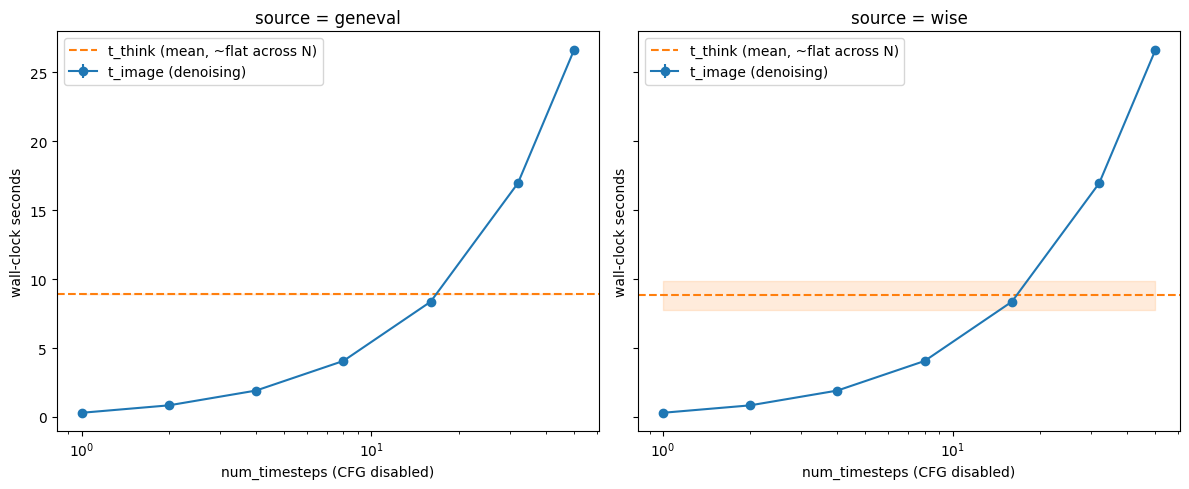

In [12]:
block_a = ok[ok["block"] == "A"]

fig, axes = plt.subplots(1, len(block_a["source"].unique()), figsize=(6 * block_a["source"].nunique(), 5), sharey=True)
if block_a["source"].nunique() == 1:
    axes = [axes]

for ax, source in zip(axes, sorted(block_a["source"].unique())):
    sub = block_a[block_a["source"] == source]
    grp = (
        sub.groupby("num_timesteps")
        .agg(t_image_mean=("t_image", "mean"), t_image_std=("t_image", "std"),
             t_think_mean=("t_think", "mean"), t_think_std=("t_think", "std"))
        .reset_index()
        .sort_values("num_timesteps")
    )
    ax.errorbar(grp["num_timesteps"], grp["t_image_mean"], yerr=grp["t_image_std"],
                marker="o", label="t_image (denoising)")
    think_mean = grp["t_think_mean"].mean()
    think_std = grp["t_think_std"].mean()
    ax.axhline(think_mean, color="C1", linestyle="--", label="t_think (mean, ~flat across N)")
    ax.fill_between(grp["num_timesteps"], think_mean - think_std, think_mean + think_std,
                     color="C1", alpha=0.15)
    ax.set_xscale("log")
    ax.set_xlabel("num_timesteps (CFG disabled)")
    ax.set_ylabel("wall-clock seconds")
    ax.set_title(f"source = {source}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "crossover_curve.png"), dpi=150)
plt.show()


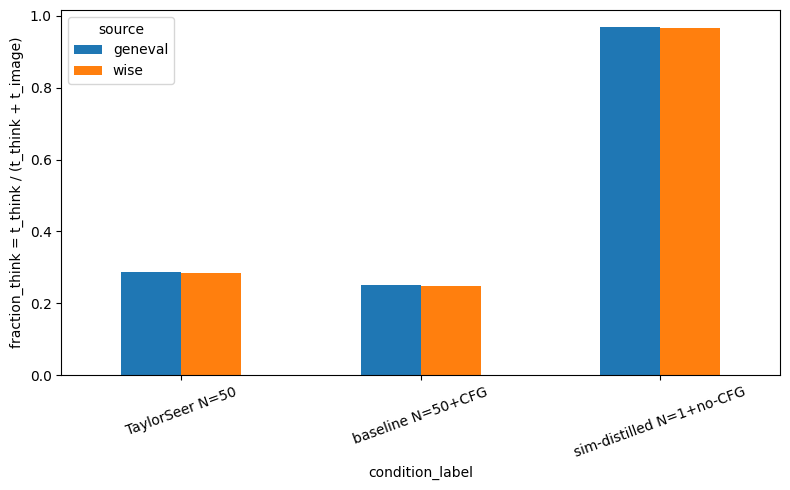

In [13]:
headline = ok[
    ((ok["block"] == "A") & (ok["num_timesteps"] == 50))
    | ((ok["block"] == "A") & (ok["num_timesteps"] == min(NUM_TIMESTEPS_LIST)))
    | ((ok["block"] == "B") & (ok["enable_taylorseer"] == True))  # noqa: E712
].copy()


def _label(r):
    if r["block"] == "A" and r["num_timesteps"] == 50:
        return "baseline N=50+CFG"
    if r["block"] == "A":
        return f"sim-distilled N={r['num_timesteps']}+no-CFG"
    return "TaylorSeer N=50"


headline["condition_label"] = headline.apply(_label, axis=1)
pivot = headline.groupby(["condition_label", "source"])["fraction_think"].mean().unstack()
pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("fraction_think = t_think / (t_think + t_image)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fraction_think_bar.png"), dpi=150)
plt.show()


In [14]:
baseline_by_prompt = (
    ok[(ok["block"] == "A") & (ok["num_timesteps"] == 50)]
    .groupby("prompt")["fraction_think"].mean()
)
distilled_by_prompt = (
    ok[(ok["block"] == "A") & (ok["num_timesteps"] == min(NUM_TIMESTEPS_LIST))]
    .groupby("prompt")["fraction_think"].mean()
)

common_prompts = baseline_by_prompt.index.intersection(distilled_by_prompt.index)
print(f"Paired prompts: {len(common_prompts)}")

if len(common_prompts) >= 1:
    stat, p_value = wilcoxon(baseline_by_prompt.loc[common_prompts], distilled_by_prompt.loc[common_prompts])
    print(f"Wilcoxon signed-rank: statistic={stat:.4f}, p={p_value:.6f}")
    print("(样本量很小时 p 值参考意义有限——这就是为什么要在放开到完整规模前先跑 pilot 探路,"
          "确认流程通了之后,再用足够多的 prompt 重新跑一次出正式结论)")
else:
    print("没有配对上的 prompt,检查 baseline / distilled 两个 condition 是否都跑成功了。")


Paired prompts: 6
Wilcoxon signed-rank: statistic=0.0000, p=0.031250
(样本量很小时 p 值参考意义有限——这就是为什么要在放开到完整规模前先跑 pilot 探路,确认流程通了之后,再用足够多的 prompt 重新跑一次出正式结论)


## 12. 局限性小结 + 图像质量对比

下面重新跑一次同一个 prompt,分别用 baseline(N=50, CFG on)和"模拟蒸馏"(N=最小值, 去CFG)设置,保留生成图像做并排对比——**目的是让"这只是时延代理、不代表质量"这句话有图有真相**,不是空口白话。少步数 + 无 CFG 的图片预期会明显更模糊/更不服从 prompt,这是正常的,因为原始权重从未针对少步数场景训练过。


100%|██████████| 49/49 [00:26<00:00,  1.86it/s]
0it [00:00, ?it/s]


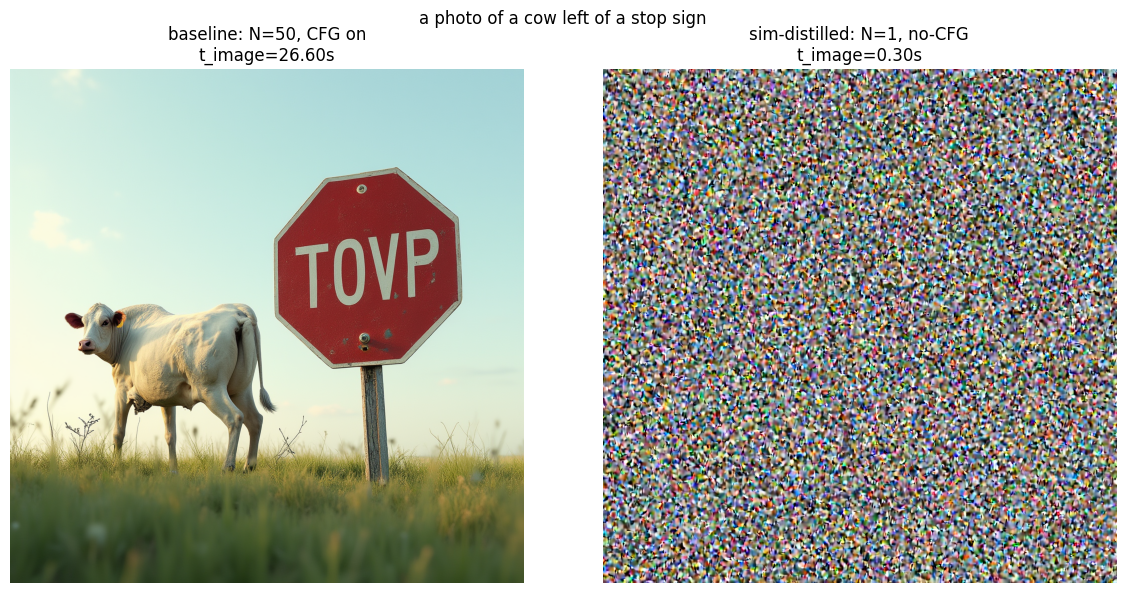

In [15]:
_quality_prompt = sampled_prompts[0]["prompt"]

_baseline_trial = run_trial(_quality_prompt, block_a_conditions[0], seed=SEED_BASE, return_image=True)
_distilled_trial = run_trial(
    _quality_prompt,
    [c for c in block_a_conditions if c["num_timesteps"] == min(NUM_TIMESTEPS_LIST)][0],
    seed=SEED_BASE,
    return_image=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(_baseline_trial["image"])
axes[0].set_title(f"baseline: N=50, CFG on\nt_image={_baseline_trial['t_image']:.2f}s")
axes[0].axis("off")
axes[1].imshow(_distilled_trial["image"])
axes[1].set_title(f"sim-distilled: N={min(NUM_TIMESTEPS_LIST)}, no-CFG\nt_image={_distilled_trial['t_image']:.2f}s")
axes[1].axis("off")
fig.suptitle(_quality_prompt[:100])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "quality_comparison.png"), dpi=150)
plt.show()


**局限性重申**:

1. 无真实步数蒸馏权重——上面两张图的画质差距就是证据,`num_timesteps`/CFG 的调整只是计算量的代理,不是有效的推理配置。
2. 单 GPU、bf16、无 device_map 假设——多卡/量化环境下的绝对数值会漂移。
3. 结果与硬件强相关,本次运行的硬件是:见第 1 节打印的 `torch.cuda.get_device_name(0)`,以及本表 `hardware` 列。
4. think 长度分布只反映 GenEval + WISE 这两个 prompt 数据源,不是"think 模式"的普遍规律——真实产品场景的 prompt 分布可能完全不同。


## 13.(可选,默认跳过)`torch.profiler` 补充诊断

仓库里没有任何 profiler 使用先例,这里只是补充诊断手段,**只对单个代表性 trial 跑,不要跑完整 sweep**(profiler 本身有明显开销,会污染计时)。默认这个 cell 不执行(`RUN_PROFILER = False`)。


In [ ]:
RUN_PROFILER = False

if RUN_PROFILER:
    from torch.profiler import profile, ProfilerActivity

    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=False) as prof:
        run_trial(sampled_prompts[0]["prompt"], block_a_conditions[0], seed=SEED_BASE)
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))
